# Import all Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Data

In [2]:
Sales_DF = pd.read_csv("D:\OneDrive\Desktop\Interview Prepe\Practical Exam\Retail Sales\Sales.csv")
Product_DF = pd.read_csv("D:\OneDrive\Desktop\Interview Prepe\Practical Exam\Retail Sales\Product.csv")

Sales_DF

,sale_id,month,product_id,region,quantity,unit_price
0,1,Jan,P1,North,12,50
1,2,Jan,P2,South,20,10
2,3,Jan,P3,North,3,500
3,4,Jan,P4,West,2,800
4,5,Feb,P1,South,15,50
5,6,Feb,P2,West,30,10
6,7,Feb,P3,North,4,500
7,8,Feb,P4,South,3,800
8,9,Mar,P1,West,10,50
9,10,Mar,P2,North,25,10


In [3]:
Product_DF

,product_id,product,category
0,P1,Notebook,Stationery
1,P2,Pen,Stationery
2,P3,Mouse,Electronics
3,P4,Keyboard,Electronics


# Check Data Types

In [4]:
print(Sales_DF.dtypes)
print("\n")
print(Product_DF.dtypes)

sale_id        int64
month         object
product_id    object
region        object
quantity       int64
unit_price     int64
dtype: object


product_id    object
product       object
category      object
dtype: object


# Remove Exact Duplicates 

In [5]:
print(f"Rows before remove Duplicates : {len(Sales_DF)}")
Remove_Duplicate = Sales_DF.drop_duplicates()
print(f"Rows before remove Duplicates : {len(Remove_Duplicate)}")

Rows before remove Duplicates : 13
Rows before remove Duplicates : 12


# Merge Sales & Product with Product ID

In [6]:
Merged = Remove_Duplicate.merge(Product_DF , on = "product_id" , how = "left")
Merged

,sale_id,month,product_id,region,quantity,unit_price,product,category
0,1,Jan,P1,North,12,50,Notebook,Stationery
1,2,Jan,P2,South,20,10,Pen,Stationery
2,3,Jan,P3,North,3,500,Mouse,Electronics
3,4,Jan,P4,West,2,800,Keyboard,Electronics
4,5,Feb,P1,South,15,50,Notebook,Stationery
5,6,Feb,P2,West,30,10,Pen,Stationery
6,7,Feb,P3,North,4,500,Mouse,Electronics
7,8,Feb,P4,South,3,800,Keyboard,Electronics
8,9,Mar,P1,West,10,50,Notebook,Stationery
9,10,Mar,P2,North,25,10,Pen,Stationery


# Calculate Revenue

In [7]:
Merged["Revenue"] = Merged["unit_price"] * Merged["quantity"]
Merged

,sale_id,month,product_id,region,quantity,unit_price,product,category,Revenue
0,1,Jan,P1,North,12,50,Notebook,Stationery,600
1,2,Jan,P2,South,20,10,Pen,Stationery,200
2,3,Jan,P3,North,3,500,Mouse,Electronics,1500
3,4,Jan,P4,West,2,800,Keyboard,Electronics,1600
4,5,Feb,P1,South,15,50,Notebook,Stationery,750
5,6,Feb,P2,West,30,10,Pen,Stationery,300
6,7,Feb,P3,North,4,500,Mouse,Electronics,2000
7,8,Feb,P4,South,3,800,Keyboard,Electronics,2400
8,9,Mar,P1,West,10,50,Notebook,Stationery,500
9,10,Mar,P2,North,25,10,Pen,Stationery,250


# Group Summary

In [8]:
Category_Summary = Merged.groupby("category" , as_index = False)["Revenue"].sum().sort_values("Revenue", ascending = False)
Category_Summary

,category,Revenue
0,Electronics,13200
1,Stationery,2600


# Highest Revenue Product

In [9]:
Highest_Product = Category_Summary.iloc[0]
Total_Revnue = Merged["Revenue"].sum()

Highest_Product_PCT = Highest_Product["Revenue"] / Total_Revnue * 100

print(f"Highest Product Category : {Highest_Product["category"]}")
print(f"Highest Product Category (in Parcentage) : {round(Highest_Product_PCT , 2)} %")

Highest Product Category : Electronics
Highest Product Category (in Parcentage) : 83.54 %


# Monthly Revenue

In [10]:
Monthly_Revenue = pd.pivot_table(Merged , values = "Revenue" , index = "month" , aggfunc = "sum")
Monthly_Revenue

,Revenue
month,
Feb,5450
Jan,3900
Mar,6450


# Regional Revenue

In [11]:
Regional_revenue = Merged.groupby("region")["Revenue"].sum().sort_values(ascending = False)
Regional_revenue

region
South    5850
West     5600
North    4350
Name: Revenue, dtype: int64

# Monthly Revenue Chart (Bar) 

<Figure size 800x500 with 0 Axes>

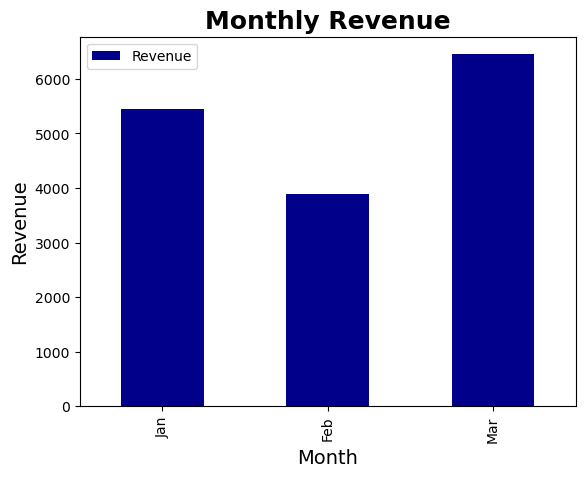

In [12]:
month_order = ["Jan" , "Feb" , "Mar"]

Monthly_Revenue.index = month_order


plt.figure(figsize = (8 , 5))

Monthly_Revenue.plot(kind = "bar" , color = "darkblue")

plt.title("Monthly Revenue" , fontsize = 18 , fontweight = "bold")
plt.xlabel("Month" , fontsize = 14)
plt.ylabel("Revenue" , fontsize = 14)


plt.savefig("output/python_chart.png", dpi=300)

plt.show()

# Export Clean Data

In [13]:
import os

os.makedirs("output" , exist_ok = True)

Merged.to_csv("output/clean_data.csv")

# Export Category Summary

In [14]:
import os

os.makedirs("output" , exist_ok = True)
Regional_revenue.to_csv("output/python_summary.csv" , index = False)

# Final Summary

In [15]:
Revenue_Per_Transection = round(Merged["Revenue"].sum() / Merged["sale_id"].nunique() , 2)

print("--------------------------------------------")
print("               Final Summary                ")
print("--------------------------------------------")

print(f"\nTotal Revenue : {Merged["Revenue"].sum()}")
print(f"Total Quantity : {Merged["quantity"].sum()}")
print(f"Revenue Per Transection : {Revenue_Per_Transection}")

print("\n--------------------------------------------")

--------------------------------------------
               Final Summary                
--------------------------------------------

Total Revenue : 15800
Total Quantity : 133
Revenue Per Transection : 1316.67

--------------------------------------------


In [16]:
print("Python Analysis Completed Successfully !...")

Python Analysis Completed Successfully !...


In [17]:
DF = pd.read_csv("output/python_summary.csv")
DF

,Revenue
0,5850
1,5600
2,4350


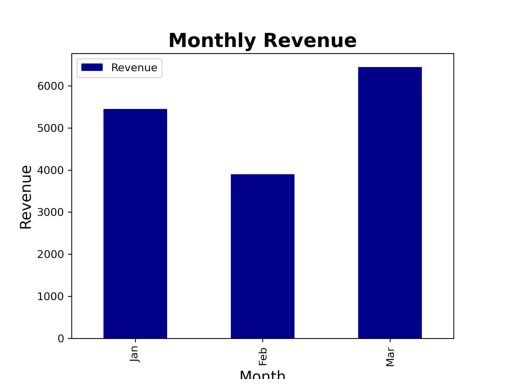

In [18]:
from PIL import Image

chart = Image.open("output/python_chart.png")

plt.imshow(chart)
plt.axis("off")
plt.show()

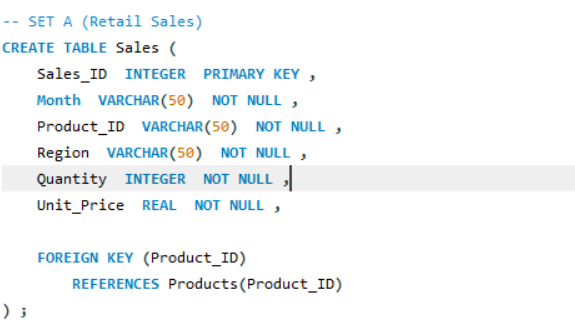

In [37]:
from IPython.display import Image

Image(filename = "Screenshot 2026-09-25 190904.png" , width = 300 , height = 200)